# 排序算法实现

本实验实现冒泡排序、选择排序和快速排序算法，并通过可视化界面演示排序过程。


## 一、构造测试数据

构造三种情况的1000个数值型数据集合：
1. 本身正序
2. 本身逆序
3. 随机顺序


数据规模: 1000

正序数据前10个: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
逆序数据前10个: [999, 998, 997, 996, 995, 994, 993, 992, 991, 990]
随机数据前10个: [1824, 409, 4506, 4012, 3657, 2286, 1679, 8935, 1424, 9674]


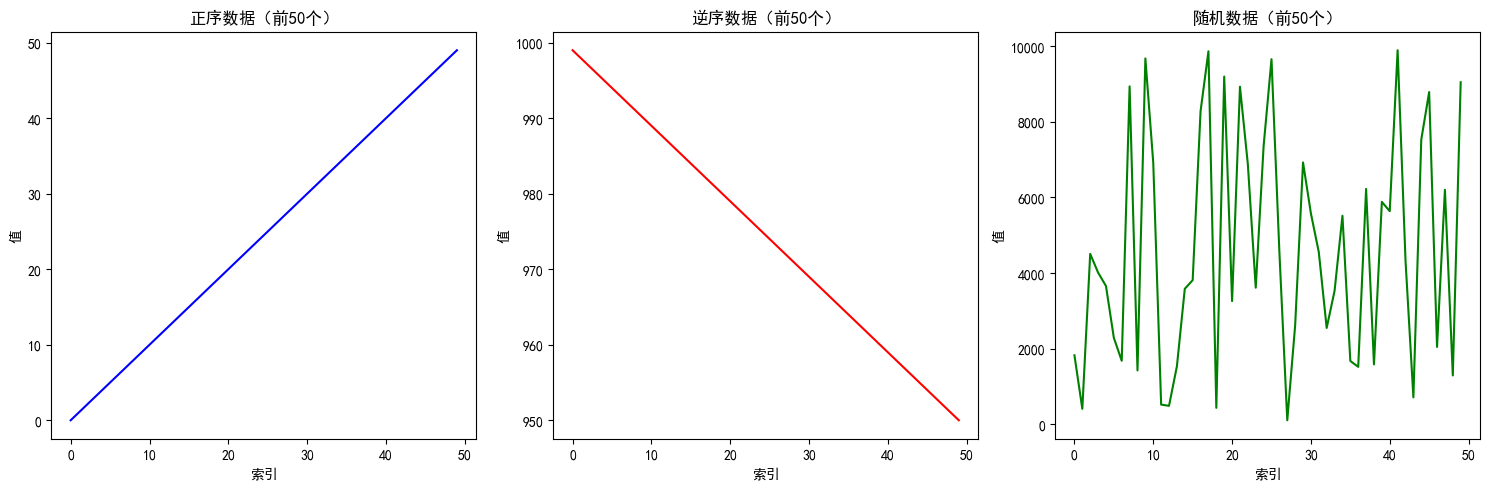

In [1]:
import random
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['font.sans-serif'] = ['SimHei', 'DejaVu Sans']
matplotlib.rcParams['axes.unicode_minus'] = False

random.seed(42)

n = 1000

sorted_data = list(range(n))

reversed_data = list(range(n-1, -1, -1))

random_data = random.sample(range(n * 10), n)

print(f"数据规模: {n}")
print(f"\n正序数据前10个: {sorted_data[:10]}")
print(f"逆序数据前10个: {reversed_data[:10]}")
print(f"随机数据前10个: {random_data[:10]}")

plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.plot(sorted_data[:50], 'b-', label='正序')
plt.title('正序数据（前50个）')
plt.xlabel('索引')
plt.ylabel('值')

plt.subplot(1, 3, 2)
plt.plot(reversed_data[:50], 'r-', label='逆序')
plt.title('逆序数据（前50个）')
plt.xlabel('索引')
plt.ylabel('值')

plt.subplot(1, 3, 3)
plt.plot(random_data[:50], 'g-', label='随机')
plt.title('随机数据（前50个）')
plt.xlabel('索引')
plt.ylabel('值')

plt.tight_layout()
plt.show()


## 二、冒泡排序

冒泡排序：重复遍历数组，比较相邻元素，如果顺序错误就交换它们。


冒泡排序测试结果：
正序数据: 耗时 0.0000s, 排序正确: True
逆序数据: 耗时 0.3162s, 排序正确: True
随机数据: 耗时 0.2162s, 排序正确: True


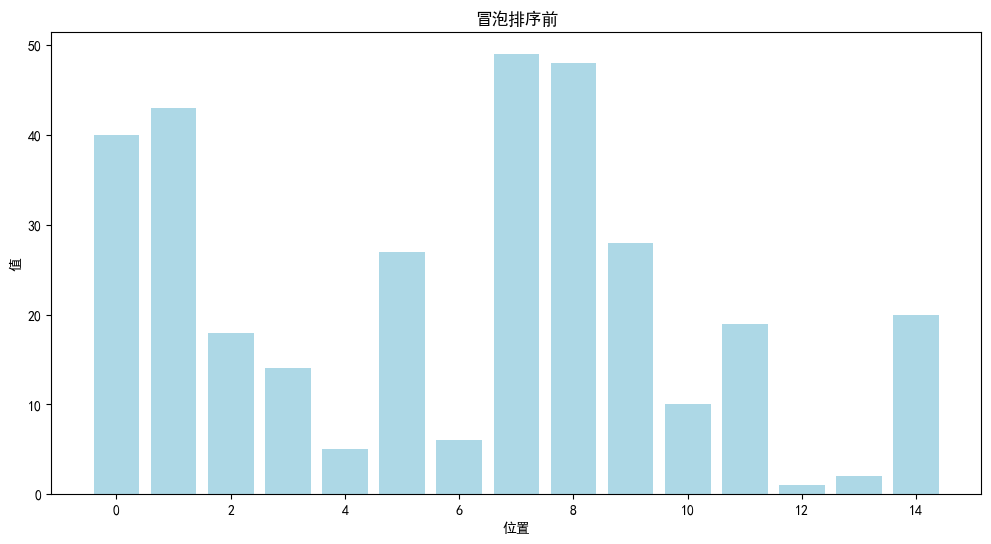

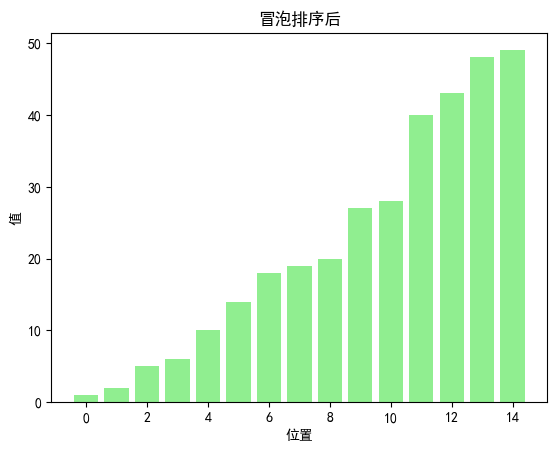

In [2]:
def bubble_sort(arr):
    arr = arr.copy()
    n = len(arr)
    for i in range(n):
        swapped = False
        for j in range(0, n-i-1):
            if arr[j] > arr[j+1]:
                arr[j], arr[j+1] = arr[j+1], arr[j]
                swapped = True
        if not swapped:
            break
    return arr

import time

test_data = [('正序', sorted_data), ('逆序', reversed_data), ('随机', random_data)]

print("冒泡排序测试结果：")
print("=" * 50)

for name, data in test_data:
    start = time.time()
    result = bubble_sort(data)
    end = time.time()
    is_sorted = result == sorted(result)
    print(f"{name}数据: 耗时 {end-start:.4f}s, 排序正确: {is_sorted}")

plt.figure(figsize=(12, 6))

demo_data = random.sample(range(50), 15)
plt.bar(range(len(demo_data)), demo_data, color='lightblue')
plt.title('冒泡排序前')
plt.xlabel('位置')
plt.ylabel('值')
plt.show()

sorted_demo = bubble_sort(demo_data)
plt.bar(range(len(sorted_demo)), sorted_demo, color='lightgreen')
plt.title('冒泡排序后')
plt.xlabel('位置')
plt.ylabel('值')
plt.show()


## 三、选择排序

选择排序：每次从未排序部分选择最小元素，放到已排序部分的末尾。


选择排序测试结果：
正序数据: 耗时 0.0950s, 排序正确: True
逆序数据: 耗时 0.1115s, 排序正确: True
随机数据: 耗时 0.0699s, 排序正确: True


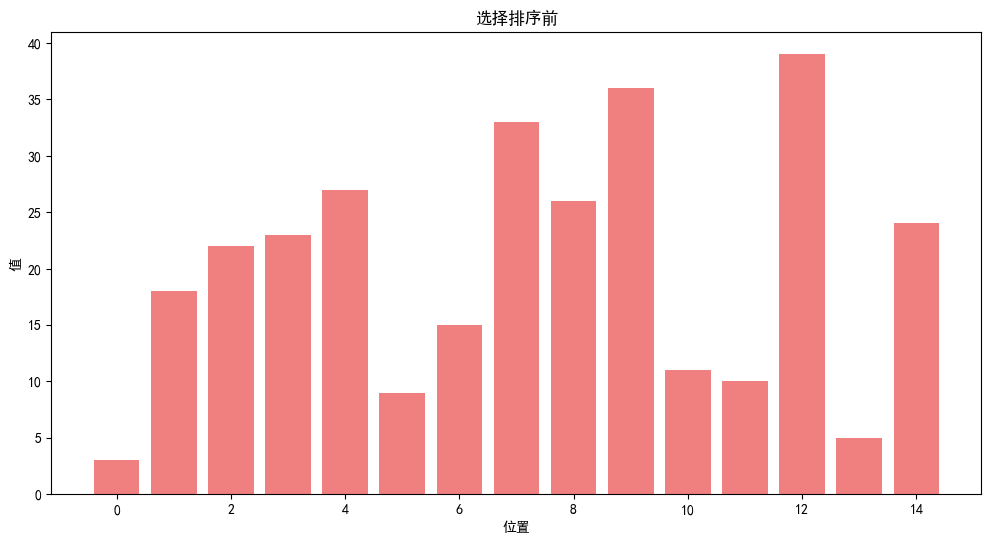

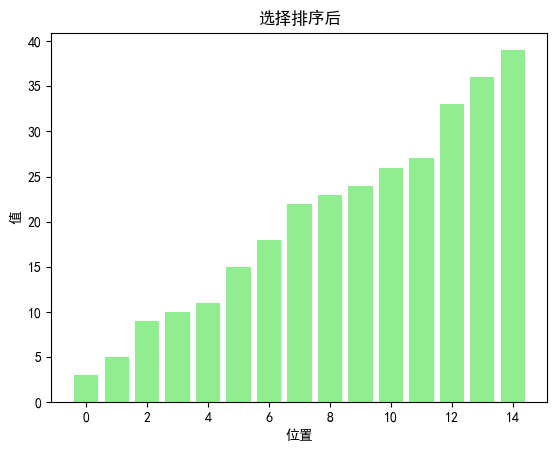

In [3]:
def selection_sort(arr):
    arr = arr.copy()
    n = len(arr)
    for i in range(n):
        min_idx = i
        for j in range(i+1, n):
            if arr[j] < arr[min_idx]:
                min_idx = j
        arr[i], arr[min_idx] = arr[min_idx], arr[i]
    return arr

print("选择排序测试结果：")
print("=" * 50)

for name, data in test_data:
    start = time.time()
    result = selection_sort(data)
    end = time.time()
    is_sorted = result == sorted(result)
    print(f"{name}数据: 耗时 {end-start:.4f}s, 排序正确: {is_sorted}")

plt.figure(figsize=(12, 6))

demo_data = random.sample(range(50), 15)
plt.bar(range(len(demo_data)), demo_data, color='lightcoral')
plt.title('选择排序前')
plt.xlabel('位置')
plt.ylabel('值')
plt.show()

sorted_demo = selection_sort(demo_data)
plt.bar(range(len(sorted_demo)), sorted_demo, color='lightgreen')
plt.title('选择排序后')
plt.xlabel('位置')
plt.ylabel('值')
plt.show()


## 四、快速排序

快速排序：选择基准元素，将数组分为小于基准和大于基准的两部分，递归排序。


快速排序测试结果：
正序数据: 耗时 0.2632s, 排序正确: True
逆序数据: 耗时 0.1384s, 排序正确: True
随机数据: 耗时 0.0030s, 排序正确: True


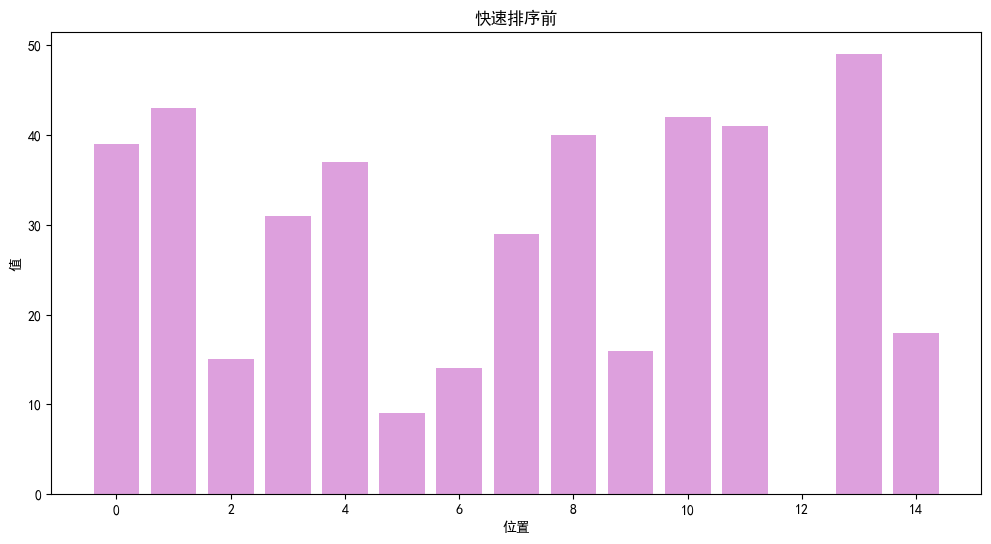

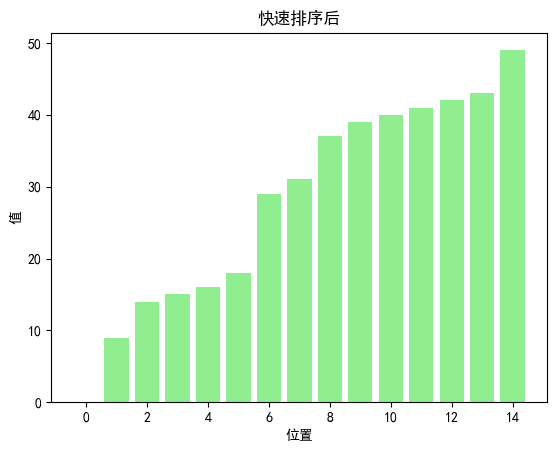

In [4]:
def quick_sort(arr):
    arr = arr.copy()
    
    def partition(low, high):
        pivot = arr[high]
        i = low - 1
        for j in range(low, high):
            if arr[j] <= pivot:
                i = i + 1
                arr[i], arr[j] = arr[j], arr[i]
        arr[i + 1], arr[high] = arr[high], arr[i + 1]
        return i + 1
    
    def quick_sort_helper(low, high):
        if low < high:
            pi = partition(low, high)
            quick_sort_helper(low, pi - 1)
            quick_sort_helper(pi + 1, high)
    
    quick_sort_helper(0, len(arr) - 1)
    return arr

print("快速排序测试结果：")
print("=" * 50)

for name, data in test_data:
    start = time.time()
    result = quick_sort(data)
    end = time.time()
    is_sorted = result == sorted(result)
    print(f"{name}数据: 耗时 {end-start:.4f}s, 排序正确: {is_sorted}")

plt.figure(figsize=(12, 6))

demo_data = random.sample(range(50), 15)
plt.bar(range(len(demo_data)), demo_data, color='plum')
plt.title('快速排序前')
plt.xlabel('位置')
plt.ylabel('值')
plt.show()

sorted_demo = quick_sort(demo_data)
plt.bar(range(len(sorted_demo)), sorted_demo, color='lightgreen')
plt.title('快速排序后')
plt.xlabel('位置')
plt.ylabel('值')
plt.show()


## 五、三种排序算法对比

对比三种排序算法在不同数据情况下的性能表现。


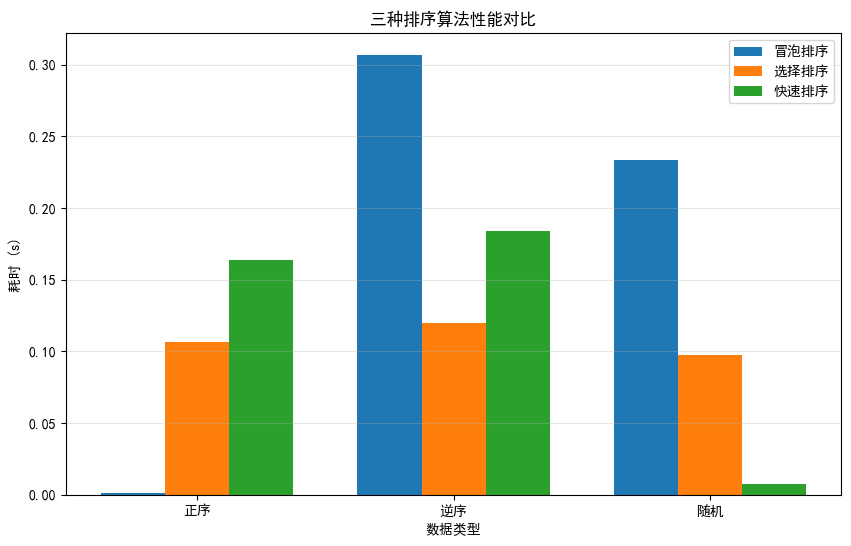

详细性能数据：
算法         正序         逆序         随机        
------------------------------------------------------------
冒泡排序       0.0010     0.3069     0.2332    
选择排序       0.1062     0.1196     0.0972    
快速排序       0.1638     0.1842     0.0071    


In [5]:
algorithms = {
    '冒泡排序': bubble_sort,
    '选择排序': selection_sort,
    '快速排序': quick_sort
}

results = {}

for algo_name, algo_func in algorithms.items():
    results[algo_name] = []
    for name, data in test_data:
        start = time.time()
        algo_func(data)
        end = time.time()
        results[algo_name].append(end - start)

import numpy as np

x = np.arange(len(test_data))
width = 0.25

plt.figure(figsize=(10, 6))

for i, (algo_name, times) in enumerate(results.items()):
    plt.bar(x + i * width, times, width, label=algo_name)

plt.xlabel('数据类型')
plt.ylabel('耗时 (s)')
plt.title('三种排序算法性能对比')
plt.xticks(x + width, ['正序', '逆序', '随机'])
plt.legend()
plt.grid(True, axis='y', alpha=0.3)
plt.show()

print("详细性能数据：")
print("=" * 60)
print(f"{'算法':<10} {'正序':<10} {'逆序':<10} {'随机':<10}")
print("-" * 60)
for algo_name, times in results.items():
    print(f"{algo_name:<10} {times[0]:<10.4f} {times[1]:<10.4f} {times[2]:<10.4f}")
